In [29]:
import os
import sys

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import requests
import matplotlib_scalebar
from matplotlib_scalebar.scalebar import ScaleBar

In [30]:
print('Python', sys.version)
print(pd.__name__, pd.__version__)
print(gpd.__name__, gpd.__version__)
print(requests.__name__, requests.__version__)
print(plt.matplotlib.__name__, plt.matplotlib.__version__)
print(matplotlib_scalebar.__name__, matplotlib_scalebar.__version__)

Python 3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]
pandas 2.3.3
geopandas 1.1.2
requests 2.32.5
matplotlib 3.10.6
matplotlib_scalebar 0.9.0


In [31]:
mx = gpd.read_file('mapa_mexico/')\
        .set_index('CLAVE')\
        .to_crs(epsg=4485)
mx.head()

,NOM_MUN,NOMEDO,CVE_EDO,CVE_MUNI,Area,geometry
CLAVE,,,,,,
02004,Tijuana,Baja California,02,004,1122.661145,"POLYGON ((-73565.018 3602427.487, -73564.403 3..."
02003,Tecate,Baja California,02,003,3670.991923,"POLYGON ((-38995.078 3617846.589, -31557.921 3..."
02002,Mexicali,Baja California,02,002,13119.275713,"POLYGON ((48160.716 3621731.593, 58570.99 3622..."
02005,Playas de Rosarito,Baja California,02,005,517.120801,"POLYGON ((-70946.724 3594803.753, -70966.034 3..."
26055,San Luis Rio Colorado,Sonora,26,055,9033.770278,"POLYGON ((127160.493 3587762.823, 127099.688 3..."


In [32]:
mx.describe

<bound method NDFrame.describe of                      NOM_MUN           NOMEDO CVE_EDO CVE_MUNI          Area  \
CLAVE                                                                          
02004                Tijuana  Baja California      02      004   1122.661145   
02003                 Tecate  Baja California      02      003   3670.991923   
02002               Mexicali  Baja California      02      002  13119.275713   
02005     Playas de Rosarito  Baja California      02      005    517.120801   
26055  San Luis Rio Colorado           Sonora      26      055   9033.770278   
...                      ...              ...     ...      ...           ...   
07087               Suchiate          Chiapas      07      087    233.070389   
20028       Ejutla de Crespo           Oaxaca      20      028    303.371304   
20028                Taniche           Oaxaca      20      028      7.201493   
20069                  La Pe           Oaxaca      20      069     31.195331   
20268 

In [33]:
# First, let's properly parse the JSON data
import json
file_path = 'complexity_eci_2026_1.json'

# Read the JSON file
#with open(file_path, 'r') as f:
#    data = json.load(f)

# Read the JSON file with UTF-8 encoding explicitly specified
with open(file_path, 'r', encoding='utf-8') as f:
    data = json.load(f)

# Check if 'data' is a key in the loaded JSON
if 'data' in data:
    # Extract the data from the nested structure
    records = []
    for item in data['data']:
        # Assuming each item is a list with [Municipality ID, Municipality, ECI]
        mun_id = item[0]
        municipality = item[1]
        eci_value = item[2]
        records.append({
            'Municipality ID': mun_id,
            'Municipality': municipality,
            'ECI': eci_value
        })
    
    # Create DataFrame from the extracted records
    eci = pd.DataFrame(records)
    
    # Now we can proceed with the original transformation
    eci = eci.assign(CLAVE=lambda x: x['Municipality ID'].astype(str).str.zfill(5)).set_index('CLAVE')
    
    # Display the result
    print(eci.head())
else:
    # If the structure is different, let's try to understand it
    print("JSON structure is different than expected. Here's what we have:")
    print(data.keys() if isinstance(data, dict) else "Data is not a dictionary")

       Municipality ID    Municipality       ECI
CLAVE                                           
01001             1001  Aguascalientes  2.811217
01002             1002        Asientos -0.227758
01003             1003        Calvillo  0.109465
01004             1004           Cosío -0.577537
01005             1005     Jesús María  2.981869


In [34]:
eci['ECI'].describe()

count    2173.000000
mean       -0.026579
std         0.979988
min        -1.330839
25%        -0.614689
50%        -0.315114
75%         0.166968
max         5.142597
Name: ECI, dtype: float64

<Axes: >

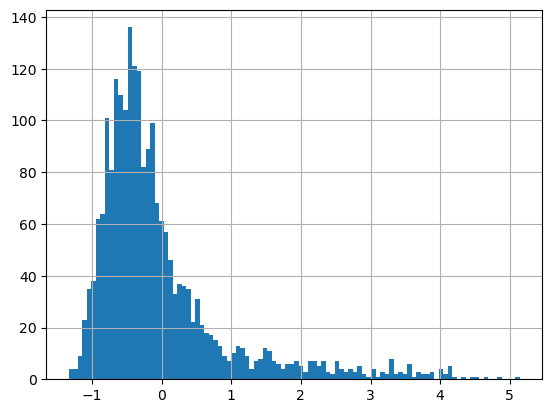

In [35]:
eci['ECI'].hist(bins=100)

In [36]:
mx = mx.join(eci, how='left')
mx.head()

,NOM_MUN,NOMEDO,CVE_EDO,CVE_MUNI,Area,geometry,Municipality ID,Municipality,ECI
CLAVE,,,,,,,,,
02004,Tijuana,Baja California,02,004,1122.661145,"POLYGON ((-73565.018 3602427.487, -73564.403 3...",2004.0,Tijuana,4.159315
02003,Tecate,Baja California,02,003,3670.991923,"POLYGON ((-38995.078 3617846.589, -31557.921 3...",2003.0,Tecate,3.316942
02002,Mexicali,Baja California,02,002,13119.275713,"POLYGON ((48160.716 3621731.593, 58570.99 3622...",2002.0,Mexicali,3.562460
02005,Playas de Rosarito,Baja California,02,005,517.120801,"POLYGON ((-70946.724 3594803.753, -70966.034 3...",2005.0,Playas de Rosarito,1.679837
26055,San Luis Rio Colorado,Sonora,26,055,9033.770278,"POLYGON ((127160.493 3587762.823, 127099.688 3...",26055.0,San Luis Río Colorado,1.598438


In [37]:
oax = mx.query('CVE_EDO=="20"')
edos = mx.dissolve(by='CVE_EDO')

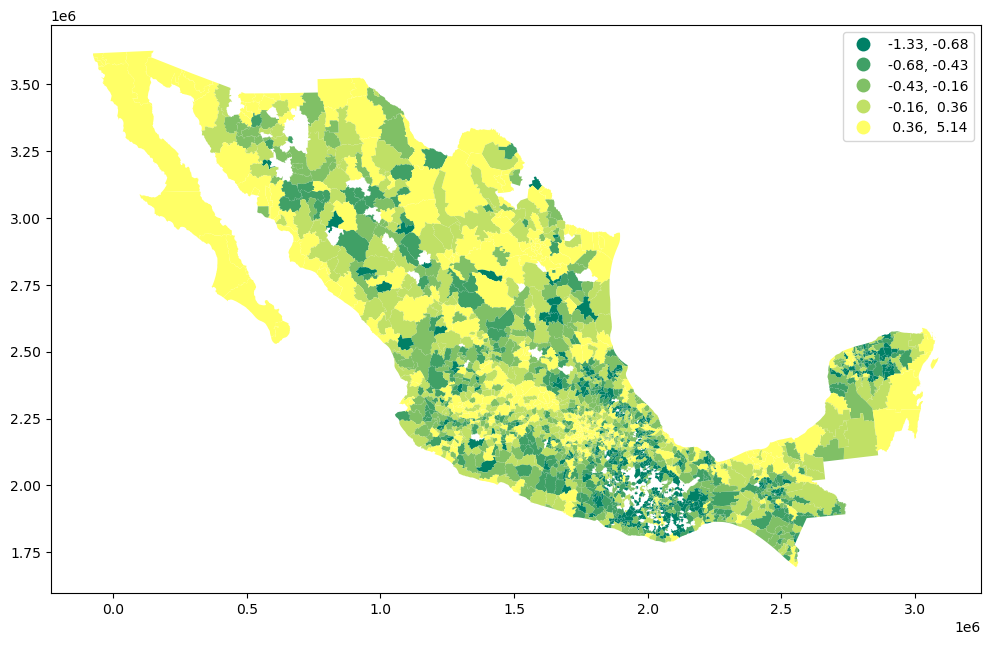

In [38]:
import mapclassify
fig, ax = plt.subplots()
# mx.plot(column='ECI', legend=True, scheme='quantiles', k=5, cmap='viridis_r', ax=ax)
mx.plot(column='ECI', legend=True, scheme='quantiles', k=5, cmap='summer', ax=ax)
fig.set_size_inches(12, 8)

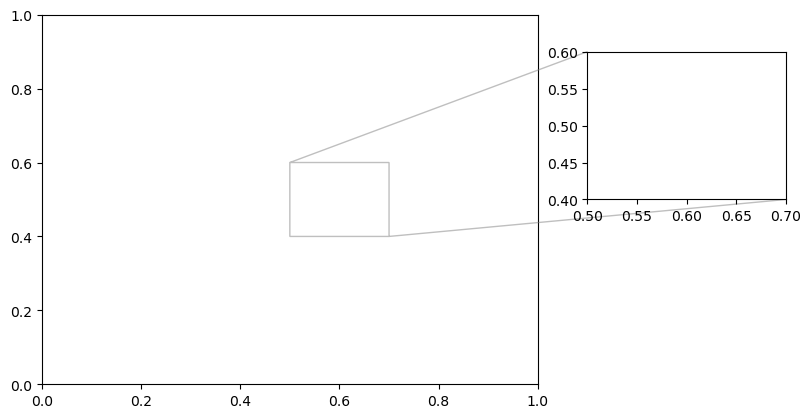

In [39]:
fig, ax = plt.subplots()
axins = ax.inset_axes([1.1, 0.5, 0.4, 0.4])
axins.set(xlim=(0.5, 0.7), ylim=(0.4, 0.6))
ax.indicate_inset_zoom(axins)

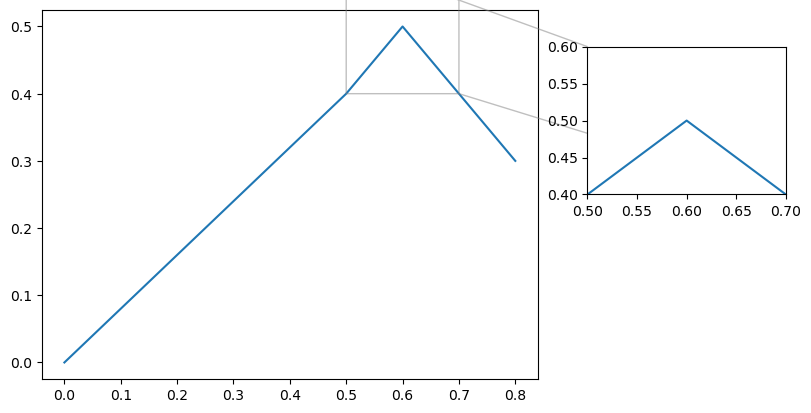

In [40]:
x = [0, 0.5, 0.6, 0.8]
y = [0, 0.4, 0.5, 0.3]
ax.plot(x, y, color='C0')
axins.plot(x, y, color='C0')
fig

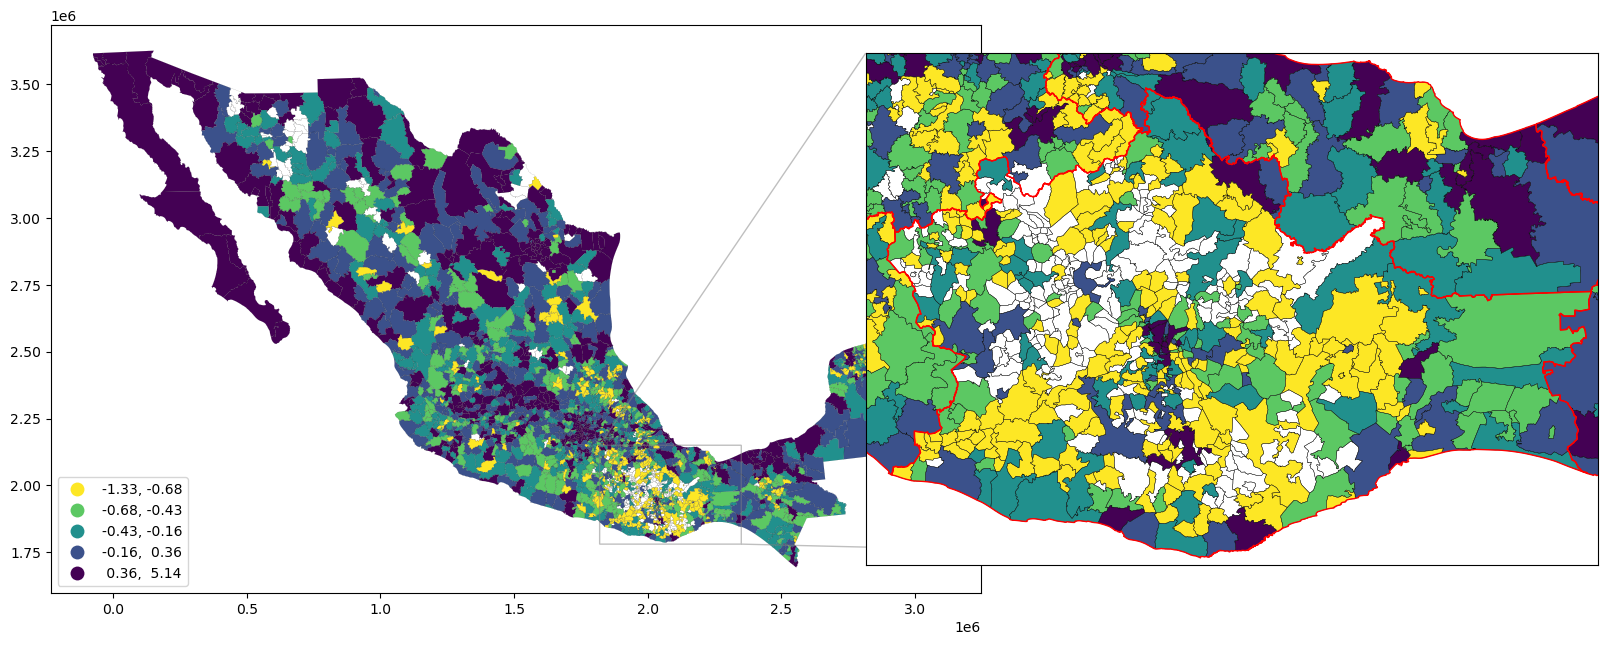

In [41]:
fig, ax = plt.subplots()
# Añade recuadro
axins = ax.inset_axes([0.82, 0.05, 0.9, 0.9])

# Gráfica principal
mx.plot(column='ECI', legend=True, ax=ax, scheme='quantiles', k=5, cmap='viridis_r', legend_kwds={'loc': 'lower left'})
mx.boundary.plot(lw=0.05, color='k', ax=ax)

# Gráfica recuadro
mx.plot(column='ECI', legend=False, ax=axins, scheme='quantiles', k=5, cmap='viridis_r')
mx.boundary.plot(lw=0.25, color='k', ax=axins)
edos.boundary.plot(lw=1, color='red', ax=axins)

# limita área a mostrar
axins.set(ylabel='', xlabel='', xlim=(1820000, 2350000), ylim=(1780000, 2150000), xticks=[], yticks=[])

# Establece líneas del recuadro a la gráfica principal
ax.indicate_inset_zoom(axins)

# Tamaño de la gráfica final
fig.set_size_inches(12, 8)

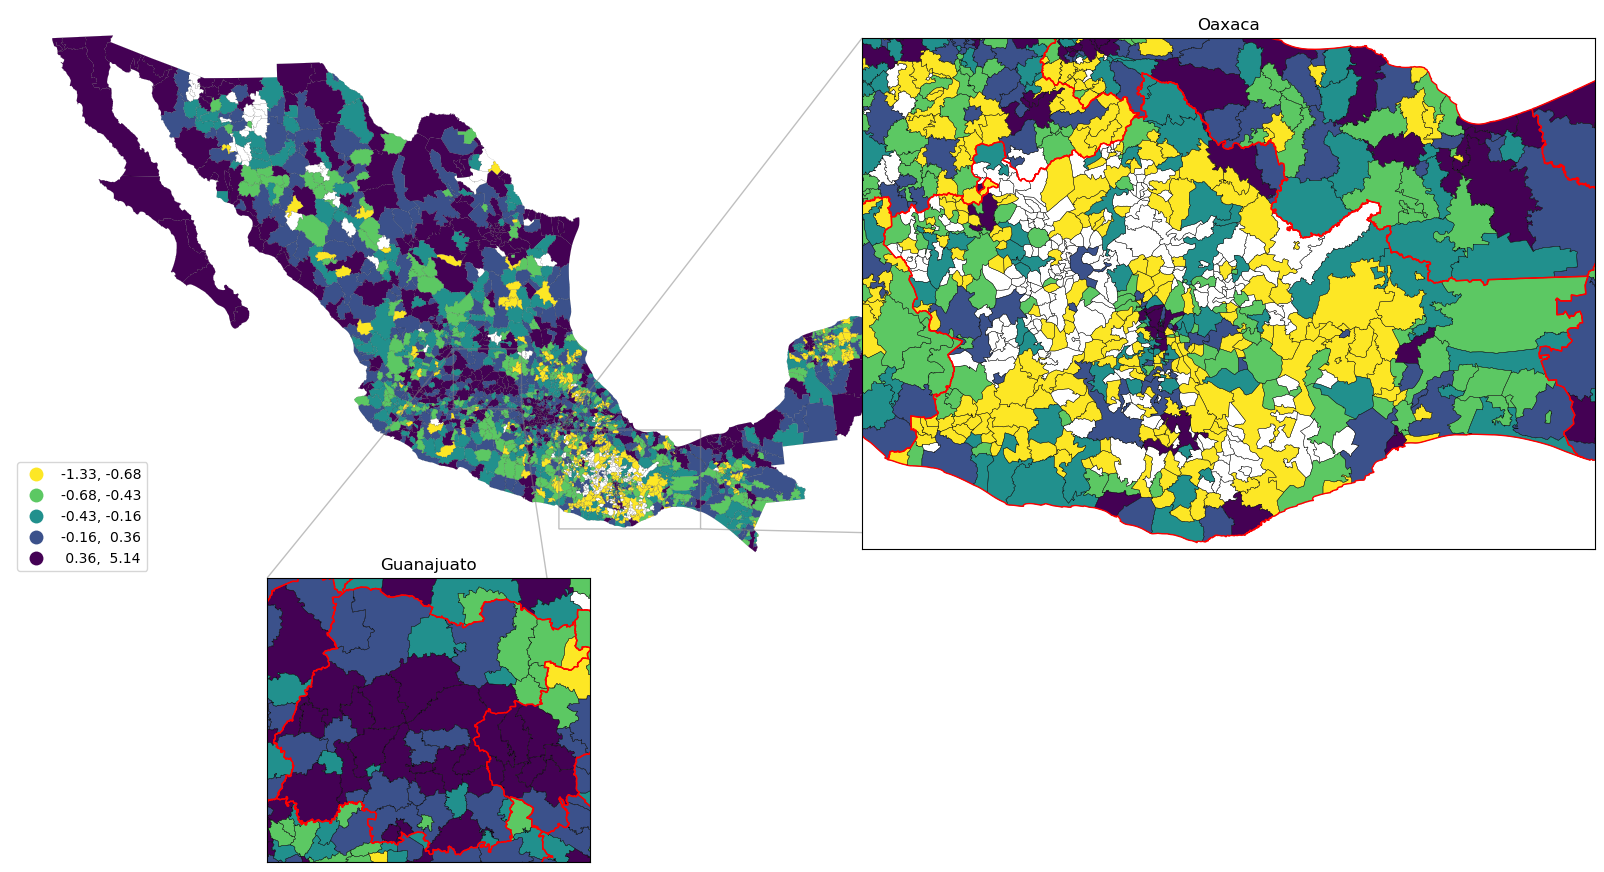

In [42]:
fig, ax = plt.subplots()
# Añade recuadro 1
axins = ax.inset_axes([0.86, 0.05, 0.9, 0.9])
# Añade recuadro 2
axins2 = ax.inset_axes([0.2, -0.5, 0.5, 0.5])

# Gráfica principal
mx.plot(column='ECI', legend=True, ax=ax, scheme='quantiles', k=5, cmap='viridis_r', legend_kwds={'loc': 'lower left'})
mx.boundary.plot(lw=0.05, color='k', ax=ax)

# Gráfica recuadro 1
mx.plot(column='ECI', legend=False, ax=axins, scheme='quantiles', k=5, cmap='viridis_r')
mx.boundary.plot(lw=0.25, color='k', ax=axins)
edos.boundary.plot(lw=1, color='red', ax=axins)

# Gráfica recuadro 2
mx.plot(column='ECI', legend=False, ax=axins2, scheme='quantiles', k=5, cmap='viridis_r')
mx.boundary.plot(lw=0.25, color='k', ax=axins2)
edos.boundary.plot(lw=1, color='red', ax=axins2)

# limita área a mostrar recuadro 1 y 2
axins.set(ylabel='', xlabel='', xlim=(1820000, 2350000), ylim=(1780000, 2150000), xticks=[], yticks=[], title='Oaxaca')
axins2.set(ylabel='', xlabel='', xlim=(1425000, 1680000), ylim=(2229203, 2453767), xticks=[], yticks=[], title='Guanajuato')

# Elimina marco de la gráfica principal
ax.set_axis_off()
# Establece líneas de los recuadros a la gráfica principal
ax.indicate_inset_zoom(axins)
ax.indicate_inset_zoom(axins2)

# Tamaño de la gráfica final
fig.set_size_inches(12, 8)

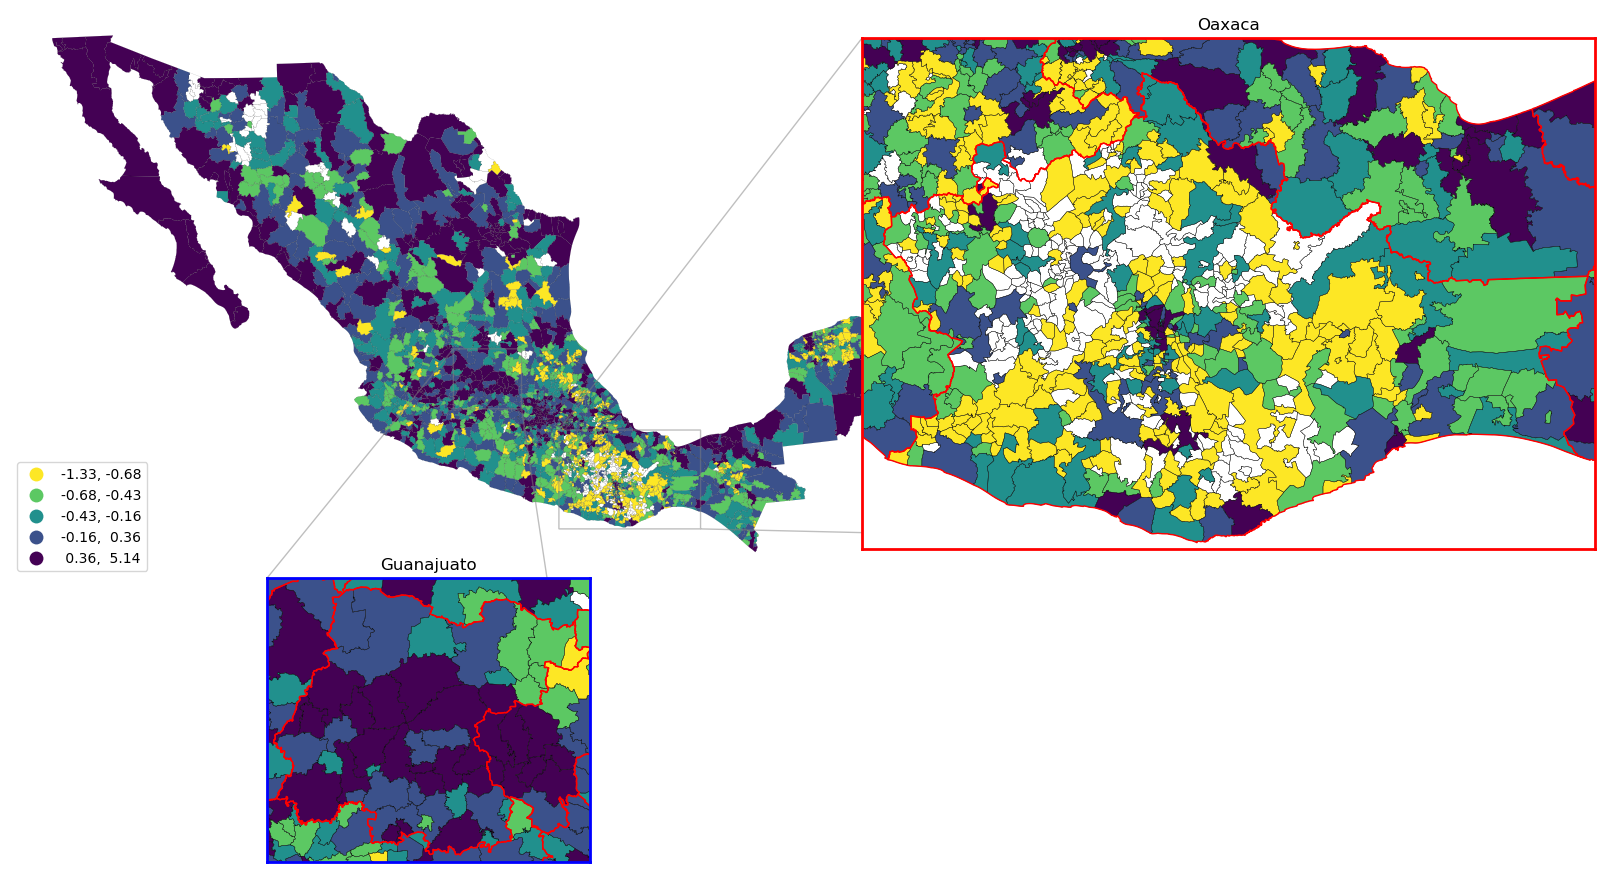

In [43]:
fig, ax = plt.subplots()
# Añade recuadro 1
axins = ax.inset_axes([0.86, 0.05, 0.9, 0.9])
# Añade recuadro 2
axins2 = ax.inset_axes([0.2, -0.5, 0.5, 0.5])

# Gráfica principal
mx.plot(column='ECI', legend=True, ax=ax, scheme='quantiles', k=5, cmap='viridis_r', legend_kwds={'loc': 'lower left'})
mx.boundary.plot(lw=0.05, color='k', ax=ax)

# Gráfica recuadro 1
mx.plot(column='ECI', legend=False, ax=axins, scheme='quantiles', k=5, cmap='viridis_r')
mx.boundary.plot(lw=0.25, color='k', ax=axins)
edos.boundary.plot(lw=1, color='red', ax=axins)

# Gráfica recuadro 2
mx.plot(column='ECI', legend=False, ax=axins2, scheme='quantiles', k=5, cmap='viridis_r')
mx.boundary.plot(lw=0.25, color='k', ax=axins2)
edos.boundary.plot(lw=1, color='red', ax=axins2)

# limita área a mostrar recuadro 1 y 2
axins.set(ylabel='', xlabel='', xlim=(1820000, 2350000), ylim=(1780000, 2150000), xticks=[], yticks=[], title='Oaxaca')
axins2.set(ylabel='', xlabel='', xlim=(1425000, 1680000), ylim=(2229203, 2453767), xticks=[], yticks=[], title='Guanajuato')

# Elimina marco de la gráfica principal
ax.set_axis_off()
# Establece líneas de los recuadros a la gráfica principal
ax.indicate_inset_zoom(axins)
ax.indicate_inset_zoom(axins2)

# Parametros para cambiar colores
color_insets = ['red', 'blue']
color_index = 0

# colorea los cuadros interiores
for p in ax.patches:
    if isinstance(p, plt.matplotlib.patches.Rectangle):
        p.set_edgecolor(color_insets[color_index])
        p.set_linewidth(2)
        color_index += 1
    else:
        # Esconde las líneas hacia la gráfica principal
        p.set_visible(False)

# Colorea el marco del recuadro 1 y aumenta grosor de línea
for sp in axins.spines.values():
    sp.set_color(color_insets[0])
    sp.set_linewidth(2)

# Colorea el marco del recuadro 2 y aumenta grosor de línea
for sp in axins2.spines.values():
    sp.set_color(color_insets[1])
    sp.set_linewidth(2)
    
# Tamaño final
fig.set_size_inches(12, 8)

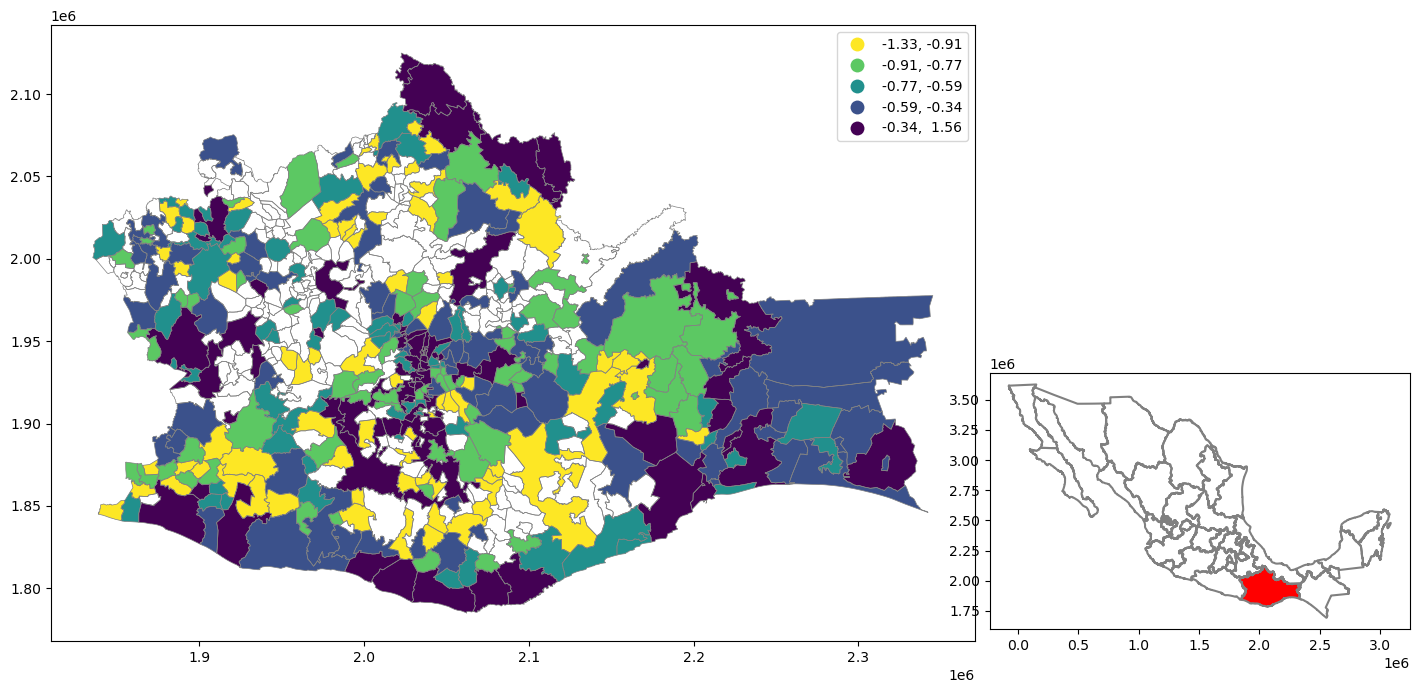

In [44]:
fig, ax = plt.subplots()
# Mapa principal
oax.plot(column='ECI', legend=True, scheme='quantiles', k=5, cmap='viridis_r', ax=ax)
# Borde de los municipios
oax.boundary.plot(linewidth=0.5, color='gray', ax=ax)
# Inserta recuadro
ax_mex = fig.add_axes([0.91, 0.11, 0.35, 0.35], )
# Dibuja los estados del país en el recuadro
edos.boundary.plot(color='gray', ax=ax_mex)
# Resalta Oaxaca con el color rojo
edos.query('CVE_EDO=="20"').plot(color='red', ax=ax_mex)
# Establece tamaño final
fig.set_size_inches(12, 8)

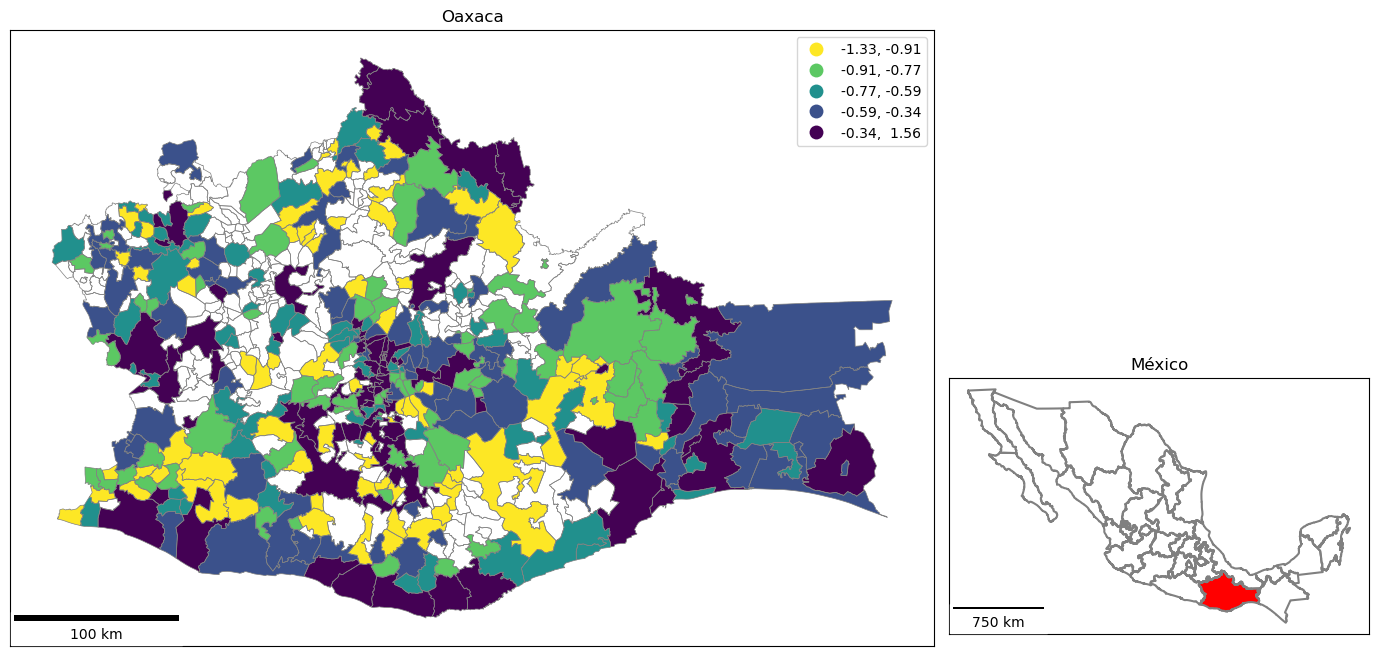

In [45]:
ax.set(xticks=[], yticks=[], title='Oaxaca')
ax_mex.set(xticks=[], yticks=[], title='México')
# Barras de escala
scalebar_oax = ScaleBar(1, "m", length_fraction=0.2, location='lower left', )
ax.add_artist(scalebar_oax)
scalebar_mex = ScaleBar(1, "m", length_fraction=0.25, location='lower left')
ax_mex.add_artist(scalebar_mex)
fig